### Agentic RAG

In [37]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")
os.environ.setdefault("USER_AGENT", "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36")

'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36'

In [38]:
import bs4
import re

from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

def clean_page_text(text):
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()

    # Trim common docs-site boilerplate that hurts retrieval quality.
    for marker in [
        "Edit this page on GitHub or file an issue.",
        "Connect these docs to Claude, VSCode, and more via MCP for real-time answers.",
        "Was this page helpful?",
        "Back to top",
    ]:
        if marker in text:
            text = text.split(marker, 1)[0].strip()

    for noise in [
        "Skip to main content",
        "Open source",
        "Search...",
        "Ask AI",
        "GitHub",
        "Try LangSmith",
        "Copy page",
    ]:
        text = text.replace(noise, " ")

    text = re.sub(r"\s+", " ", text).strip()
    return text

def _build_loader(urls, parse_only_main=True):
    bs_kwargs = {"parse_only": bs4.SoupStrainer(["main", "article"])} if parse_only_main else None
    return WebBaseLoader(
        web_paths=urls,
        header_template={"User-Agent": os.environ["USER_AGENT"]},
        requests_kwargs={"timeout": 20},
        bs_kwargs=bs_kwargs,
        bs_get_text_kwargs={"separator": " ", "strip": True},
    )

def _clean_docs(docs):
    cleaned_docs = []
    for doc in docs:
        doc.page_content = clean_page_text(doc.page_content)
        if len(doc.page_content) > 100:
            cleaned_docs.append(doc)
    return cleaned_docs

def load_web_docs(urls):
    loader = _build_loader(urls, parse_only_main=True)

    try:
        docs = loader.load()
    except Exception as exc:
        raise RuntimeError(
            "Web loading failed. Check your internet/DNS access from the notebook environment and verify the URLs are reachable."
        ) from exc

    cleaned_docs = _clean_docs(docs)

    if not cleaned_docs:
        # Fallback: some docs pages don't expose useful content inside main/article.
        fallback_loader = _build_loader(urls, parse_only_main=False)
        try:
            fallback_docs = fallback_loader.load()
        except Exception as exc:
            raise RuntimeError(
                "Web loading fallback failed. Check your internet/DNS access from the notebook environment and verify the URLs are reachable."
            ) from exc
        cleaned_docs = _clean_docs(fallback_docs)

    print(f"Loaded {len(cleaned_docs)} usable docs out of {len(urls)} URLs")
    for doc in cleaned_docs:
        print(doc.metadata.get("source"), "->", len(doc.page_content), "chars")

    if not cleaned_docs:
        raise ValueError(
            "No usable content was extracted. This usually means the pages did not load, the site blocked the request, or the parser selected empty content."
        )

    return cleaned_docs

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [39]:
urls=[
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents",
    "https://docs.langchain.com/oss/python/langgraph/graph-api"
]

docs = load_web_docs(urls)
docs


Loaded 3 usable docs out of 3 URLs
https://docs.langchain.com/oss/python/langgraph/overview -> 4505 chars
https://docs.langchain.com/oss/python/langgraph/workflows-agents -> 21910 chars
https://docs.langchain.com/oss/python/langgraph/graph-api -> 34771 chars


[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChain Docs by LangChain home page ⌘ K Navigation LangGraph overview Deep Agents LangChain LangGraph Integrations Learn Reference Contribute Python Overview Get started Install Quickstart Local server Changelog Thinking in LangGraph Workflows + agents Capabilities Persistence Durable execution Streaming Interrupts Time travel Memory Subgraphs Production Application structure Test LangSmith Studio Agent Chat UI LangSmith Deployment LangSmith Observability Frontend Overview Graph execution LangGraph APIs Graph API Functional API Runtime On this page Install Core benefits LangGraph ecosystem Acknowledgements LangGraph overview Gain control with LangGraph to design agents that reliably handl

In [40]:
len(docs)

3

In [43]:
docs_list = docs

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Add alll these text to vectordb

vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=embedding_model
)


retriever=vectorstore.as_retriever()

In [44]:
len(docs_list)

3

In [45]:
docs == docs_list

True

In [46]:
retriever.invoke("what is langgraph")

[Document(id='09553e75-ca9a-4b55-a7b7-ae946b055781', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/graph-api', 'title': 'Graph API overview - Docs by LangChain', 'language': 'en'}, page_content='computation or side-effect, and return an updated state. Edges : Functions that determine which Node to execute next based on the current state. They can be conditional branches or fixed transitions. By composing Nodes and Edges , you can create complex, looping workflows that evolve the state over time. The real power, though, comes from how LangGraph manages that state. To emphasize: Nodes and Edges are nothing more than functions—they can contain an LLM or just good ol’ code. In short: nodes do the work, edges tell what to do next . LangGraph’s underlying graph algorithm uses message passing to define a general program. When a Node completes its operation, it sends messages along one or more edges to other node(s). These recipient nodes then execute their functions, pa

In [47]:
### Retriever To Retriever Tools
from langchain_core.tools import create_retriever_tool
retriever_tool=create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",
    "Search and run information about Langgraph"
)

In [48]:
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search and run information about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x7067a4b8e840>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x7067a4b8e480>)

### Langchain Blogs- Seperate Vector Store


In [49]:
langchain_urls=[
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/langchain/agents",
    "https://docs.langchain.com/oss/python/langchain/retrieval"
]

docs = load_web_docs(langchain_urls)
docs

Loaded 3 usable docs out of 3 URLs
https://docs.langchain.com/oss/python/langchain/overview -> 4007 chars
https://docs.langchain.com/oss/python/langchain/agents -> 25425 chars
https://docs.langchain.com/oss/python/langchain/retrieval -> 10698 chars


[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain is an open source framework with a prebuilt agent architecture and integrations for any model or tool—so you can build agents that adapt as fast as the ecosystem evolves', 'language': 'en'}, page_content='LangChain overview - Docs by LangChain Docs by LangChain home page ⌘ K Navigation LangChain overview Deep Agents LangChain LangGraph Integrations Learn Reference Contribute Python Overview Get started Install Quickstart Changelog Philosophy Core components Agents Models Messages Tools Short-term memory Streaming Structured output Middleware Overview Prebuilt middleware Custom middleware Frontend Overview Patterns Integrations Advanced usage Guardrails Runtime Context engineering Model Context Protocol (MCP) Human-in-the-loop Multi-agent Retrieval Long-term memory Agent development LangSmith Studio Test Agent Chat UI Depl

In [50]:
docs_list = docs

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Add alll these text to vectordb

vectorstorelangchain=FAISS.from_documents(
    documents=doc_splits,
    embedding=embedding_model
)


retrieverlangchain=vectorstorelangchain.as_retriever()

In [51]:
from langchain_core.tools import create_retriever_tool

retriever_tool_langchain=create_retriever_tool(
    retrieverlangchain,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

In [52]:
tools=[retriever_tool,retriever_tool_langchain]

### LangGraph Workflow

In [53]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [54]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="llama-3.1-8b-instant")
llm.invoke("Hi")

AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.027015351, 'completion_tokens_details': None, 'prompt_time': 0.001699801, 'prompt_tokens_details': None, 'queue_time': 0.045694129, 'total_time': 0.028715152}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d0752-8dd2-7402-b8f6-644b54d074ad-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})

In [55]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatGroq(model="llama-3.1-8b-instant")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [56]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

# from langchain import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

from pydantic import BaseModel, Field

In [57]:
### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatGroq(model="llama-3.1-8b-instant")

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [58]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = PromptTemplate.from_template("""You are an assistant for question-answering tasks.
Use the following retrieved context to answer the question.
If the answer is not in the context, say you do not know.
Answer concisely.

Question: {question}
Context: {context}

Answer:""")

    # LLM
    llm = ChatGroq(model="llama-3.1-8b-instant")

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [59]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model="llama-3.1-8b-instant")
    response = model.invoke(msg)
    return {"messages": [response]}

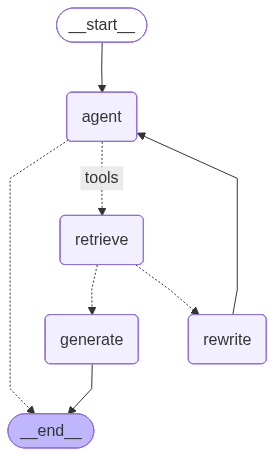

In [60]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool,retriever_tool_langchain])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [61]:
graph.invoke({"messages":"What is Langgraph?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='735e81a9-61d5-433e-9760-c3950599a24c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'q2mwbjw4k', 'function': {'arguments': '{"query":"What is Langgraph?"}', 'name': 'retriever_vector_db_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 310, 'total_tokens': 331, 'completion_time': 0.301306661, 'completion_tokens_details': None, 'prompt_time': 0.023262537, 'prompt_tokens_details': None, 'queue_time': 0.046045523, 'total_time': 0.324569198}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d0752-cc73-77a3-835f-059bd95fde1a-0', tool_calls=[{'name': 'retriever_vector_db_blog', 'args': {'query': 'What is Langgraph?'}, 'id': 'q2mwbjw4k', 'type': 'tool_call'}], invali

In [62]:
graph.invoke({"messages":"What is Langchain?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='a240521d-221c-405c-bade-8ea7606ed0e3'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '9s75g6b96', 'function': {'arguments': '{"query":"What is Langchain?"}', 'name': 'retriever_vector_langchain_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 310, 'total_tokens': 332, 'completion_time': 0.029842351, 'completion_tokens_details': None, 'prompt_time': 0.0214595, 'prompt_tokens_details': None, 'queue_time': 0.07439736, 'total_time': 0.051301851}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d0753-31cb-7061-a28c-1724208e4f27-0', tool_calls=[{'name': 'retriever_vector_langchain_blog', 'args': {'query': 'What is Langchain?'}, 'id': '9s75g6b96', 'type': 'tool_call

In [63]:
graph.invoke({"messages":"What is Machine learning?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---


{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='cf20f578-4eae-4b86-b6b2-9dffca2e2d78'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'w2w2412ex', 'function': {'arguments': '{"query":"Machine learning definition"}', 'name': 'retriever_vector_db_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 310, 'total_tokens': 330, 'completion_time': 0.030923351, 'completion_tokens_details': None, 'prompt_time': 0.021949258, 'prompt_tokens_details': None, 'queue_time': 0.045607432, 'total_time': 0.052872609}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d0753-9319-7bb2-9d26-7b5a6978f8e8-0', tool_calls=[{'name': 'retriever_vector_db_blog', 'args': {'query': 'Machine learning definition'}, 'id': 'w2w2412ex', 'typ